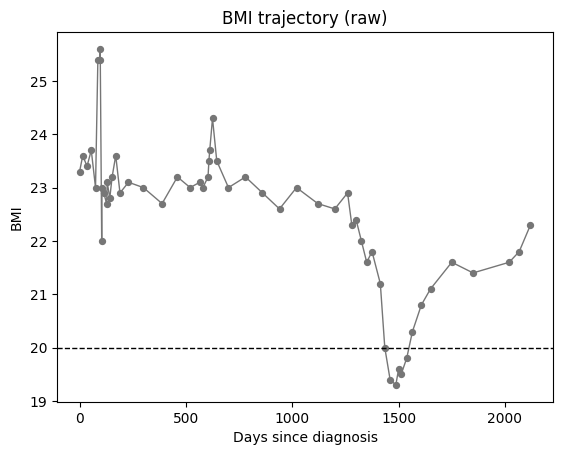

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Step 1: Load the dataset
# Required columns:
#   - patient_id: de-identified patient identifier (string)
#   - days_since_anchor: integer days since anchor/diagnosis (numeric)
#   - bmi: body mass index (numeric)
# =========================
fp = "../data/mock/example_patient_deid.csv"
bmi_df = pd.read_csv(fp)
# ==========Example walkthrough=============== 
PATIENT_ID = "EXAMPLE_PATIENT_001"
one = (bmi_df.loc[bmi_df["patient_id"] == PATIENT_ID, ["patient_id", "days_since_anchor", "bmi"]]
             .dropna()
             .sort_values("days_since_anchor")
             .reset_index(drop=True))

#   - dashed line marks BMI = 20 (BMI<20 triggers the 2% WL rule in the cachexia definition)
plt.figure()
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, color="#767676FF")
plt.scatter(one["days_since_anchor"], one["bmi"], s=18, color="#767676FF")
plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("BMI trajectory (raw)")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.show()

#one

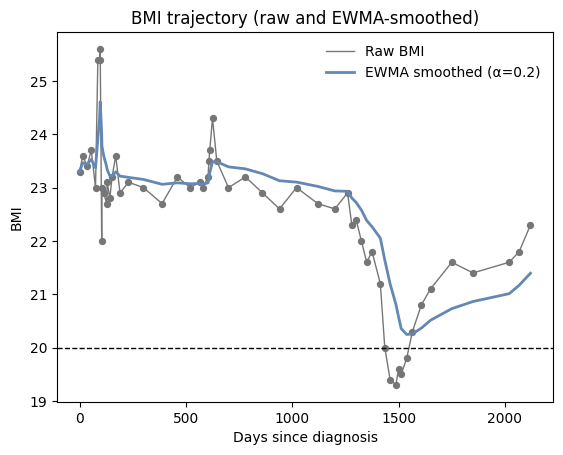

In [200]:
import numpy as np
# =========================
# Step 2: Smooth BMI
# Required columns:
#   - days_since_anchor (numeric)
#   - bmi (numeric)
# Output (adds columns):
#   - smoothed_BMI: EWMA-smoothed BMI (alpha=0.2)
#   - log_smoothed_BMI: log(smoothed_BMI), used for WL thresholding in Step 3

# =========================

def smooth_bmi_ewma(df, bmi_col="bmi", alpha=0.2, out_col="smoothed_BMI"):
    df = df.copy()
    df[out_col] = df[bmi_col].ewm(alpha=alpha, ignore_na=True).mean()
    return df

one = smooth_bmi_ewma(one, bmi_col="bmi", alpha=0.2, out_col="smoothed_BMI")
one["log_smoothed_BMI"] = np.log(one["smoothed_BMI"])



plt.figure()
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, color="#767676FF", label="Raw BMI")
plt.scatter(one["days_since_anchor"], one["bmi"], s=18, color="#767676FF")
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF", label="EWMA smoothed (α=0.2)")
plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("BMI trajectory (raw and EWMA-smoothed)")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False)
plt.show()

#one

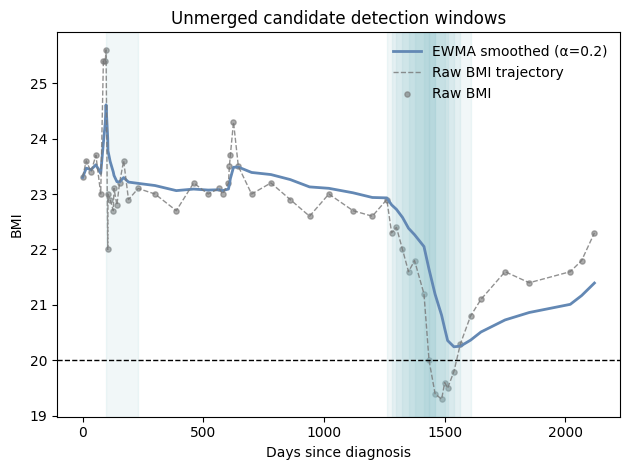

In [201]:

# =========================
# Step 3: Identify candidate (unmerged) detection windows
#   - Generate "candidate" cachexia windows before merging.
#   - Each observed timepoint t0 acts as a baseline.
#   - Look ahead 180 days: (t0, t0 + 180]
#   - Define the WL threshold in log space:
#       log_smoothed_BMI < b0 + log(1 - wl_frac)
#     and if bmi20_rule=True and baseline smoothed_BMI < 20:
#       log_smoothed_BMI < b0 + log(0.98)  # 2% WL rule
# Output:
#   - cand: DataFrame with one row per baseline timepoint that triggers a drop:
#       start_day, start_bmi, onset_day, onset_bmi, end_day, end_bmi
# # =========================


def identify_cachexia_episodes_2(
    df,
    time_col="days_since_anchor",
    bmi_col_log="log_smoothed_BMI",
    wl_frac=0.05,
    bmi20_rule=True,
    window_days=180,
):
    """
    -Identifies cachexia episode candidates pre-merged
    - Uses log_smoothed_BMI thresholding (b0 + log(0.95) or log(0.98) if BMI<20 rule)
    """
    df = df.reset_index(drop=True).copy()

    wl_log_default = np.log(1 - wl_frac)  # e.g., log(0.95)
    wl_log_lowbmi  = np.log(0.98)         # 2% WL threshold for BMI<20

    results = []

    for i in range(df.shape[0]):
        t0 = df[time_col][i]
        b0 = df[bmi_col_log][i]               # baseline log-smoothed BMI
        baseline_bmi = df["smoothed_BMI"][i]  # baseline in linear space (smoothed)
        # current_date = df["datetime"][i] 
        current_bmi  = df["bmi"][i]         

        # KEEP 180-day lookahead exactly
        df_window = df[(df[time_col] > t0) & (df[time_col] <= t0 + window_days)]

        wl_log_i = wl_log_lowbmi if (bmi20_rule and baseline_bmi < 20) else wl_log_default
        df_filtered = df_window[df_window[bmi_col_log] < b0 + wl_log_i]

        if not df_filtered.empty:
            onset_day = df_filtered[time_col].min()
            #onset_date = df_filtered.loc[df_filtered[time_col] == onset_day, "datetime"].values[0] 
            onset_bmi  = df_filtered.loc[df_filtered[time_col] == onset_day, "smoothed_BMI"].values[0]

            max_t = df_filtered[time_col].max()
            #end_date = df_filtered.loc[df_filtered[time_col] == max_t, "datetime"].values[0]  
            end_bmi  = df_filtered.loc[df_filtered[time_col] == max_t, "smoothed_BMI"].values[0]

            results.append({
                "start_day": t0,
                #"start_date": current_date,
                "start_bmi": current_bmi,
                "onset_day": onset_day,
                #"onset_date": onset_date,
                "onset_bmi": onset_bmi,
                "end_day": max_t,
                #"end_date": end_date,
                "end_bmi": end_bmi
            })

    # same as production fallback
    if len(results) == 0:
        results.append({
            "start_day": None,
            #"start_date": None,
            "start_bmi": None,
            "onset_day": None,
            #"onset_date": None,
            "onset_bmi": None,
            "end_day": None,
            #"end_date": None,
            "end_bmi": None
        })

    return pd.DataFrame(results).sort_values(["start_day", "end_day"], na_position="last").reset_index(drop=True)

# ---- identify candidate episodes ----
cand = identify_cachexia_episodes_2(
    one,
    time_col="days_since_anchor",
    bmi_col_log="log_smoothed_BMI",
    wl_frac=0.05,
    bmi20_rule=True,   # set True  to demonstrate BMI<20 rule
    window_days=180)

cand.head(10)

plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")
for _, r in cand.dropna(subset=["start_day", "end_day"]).iterrows():
    plt.axvspan(r["start_day"], r["end_day"], alpha=0.12, color="#8CC2CAFF")
plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("Unmerged candidate detection windows")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

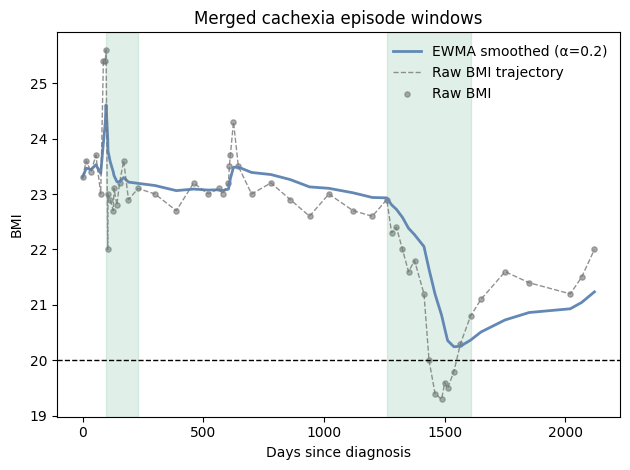

In [197]:
# =========================
# Step 4: Merge overlapping candidate windows into cachexia episodes
#   - If the next candidate's start_day <= current end_day, merge (extend end_day)
#   - Keeps the end_day/end_bmi from the last overlapping candidate
# =========================

def merge_episodes(df, start_col="start_day", end_col="end_day"):
    """
    Merges overlapping cachexia episode candidates.
      Keys:start_day, start_bmi, onset_day, onset_bmi, end_day, end_bmi
    """
    merged_episodes = []
    current_episode = None

    df = df.dropna(subset=[start_col, end_col]).copy()
    df = df.sort_values([start_col, end_col]).reset_index(drop=True)

    for i in range(df.shape[0]):
        if current_episode is None:
            current_episode = df.iloc[i].to_dict()
        elif df.loc[i, start_col] <= current_episode["end_day"]:
            # overlap => extend current
            current_episode["end_day"] = max(current_episode["end_day"], df.loc[i, end_col])
            current_episode["end_bmi"] = df.loc[i, "end_bmi"]
            # current_episode["end_date"] = df.loc[i, "end_date"]  # production (commented)
        else:
            merged_episodes.append(current_episode)
            current_episode = df.iloc[i].to_dict()

    if current_episode is not None:
        merged_episodes.append(current_episode)

    return pd.DataFrame(merged_episodes)


# ---- merge candidate windows into episodes ----
merged = merge_episodes(cand, start_col="start_day", end_col="end_day")
merged


plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in merged.dropna(subset=["start_day", "end_day"]).iterrows():
    plt.axvspan(r["start_day"], r["end_day"], alpha=0.18, color="#55AD89FF")

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("Merged cachexia episode windows")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

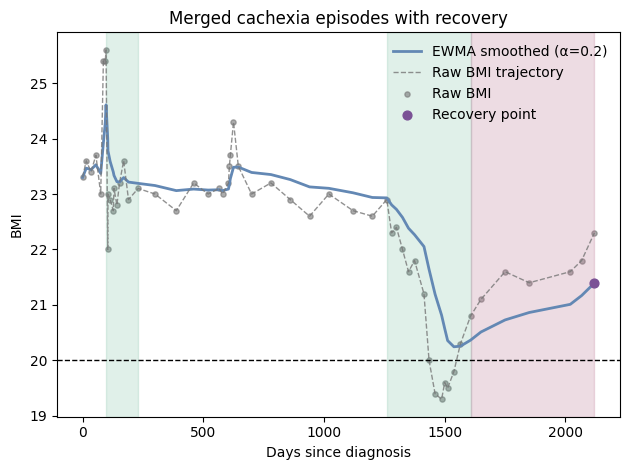

,start_day,start_bmi,onset_day,onset_bmi,end_day,end_bmi,recovery_day,recovery_bmi,recovery_smoothed_bmi
0,97.0,25.6,130.0,23.334359,230.0,23.191892,None,None,None
1,1260.0,22.9,1435.0,21.642382,1607.0,20.365517,2120,22.3,21.395143


In [209]:
# =========================
# Step 5 OPTIONAL: Identify recovery after each merged episode
#   - For each merged cachexia episode, find the first timepoint after end_day
#     where log_smoothed_BMI increases by ≥5% relative to the episode end level:
#         log_smoothed_BMI > log_end + log(1.05)
# Output (adds columns to merged):
#   - recovery_day, recovery_bmi, recovery_smoothed_bmi
# =========================

def identify_recovery_episodes(patient_data, merged_episodes_df,
                               time_col="days_since_anchor",
                               bmi_col_log="log_smoothed_BMI"):
    """
    Production-matched recovery logic (dates commented out):
      - Baseline is log-smoothed BMI at end_day
      - Recovery is first day where log-smoothed BMI > end_log + log(1.05)
      - Search window is [end_day, next_episode_start_day] or until last observation
    """
    merged_episodes_df = merged_episodes_df.copy()

    merged_episodes_df["recovery_day"] = None
    # merged_episodes_df["recovery_date"] = None
    merged_episodes_df["recovery_bmi"] = None
    merged_episodes_df["recovery_smoothed_bmi"] = None

    if merged_episodes_df["start_day"].isna().all():
        return merged_episodes_df

    for i in range(merged_episodes_df.shape[0]):
        t0 = merged_episodes_df.loc[i, "end_day"]

        if i < merged_episodes_df.shape[0] - 1:
            t1 = merged_episodes_df.loc[i + 1, "start_day"]
        else:
            t1 = patient_data[time_col].max()

        # baseline at end_day (log space)
        end_index = patient_data.loc[patient_data[time_col] == t0].index
        if len(end_index) == 0:
            continue
        end_index = end_index[0]
        b0_log = patient_data.loc[end_index, bmi_col_log]

        recovery_data = patient_data[
            (patient_data[time_col] >= t0) &
            (patient_data[time_col] <= t1) &
            (patient_data[bmi_col_log] > (b0_log + np.log(1.05)))
        ]

        if not recovery_data.empty:
            recovery_day = int(recovery_data[time_col].min())
            # recovery_date = recovery_data.loc[recovery_data[time_col] == recovery_day, "datetime"].values[0]
            recovery_bmi = float(recovery_data.loc[recovery_data[time_col] == recovery_day, "bmi"].values[0])
            recovery_smoothed_bmi = float(recovery_data.loc[recovery_data[time_col] == recovery_day, "smoothed_BMI"].values[0])

            merged_episodes_df.at[i, "recovery_day"] = recovery_day
            # merged_episodes_df.at[i, "recovery_date"] = recovery_date
            merged_episodes_df.at[i, "recovery_bmi"] = recovery_bmi
            merged_episodes_df.at[i, "recovery_smoothed_bmi"] = recovery_smoothed_bmi

    return merged_episodes_df


# ---- compute recovery (optional) ----
merged_rec = identify_recovery_episodes(
    patient_data=one,
    merged_episodes_df=merged,
    time_col="days_since_anchor",
    bmi_col_log="log_smoothed_BMI"
)

merged_rec


plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in merged_rec.dropna(subset=["start_day", "end_day"]).iterrows():
    plt.axvspan(r["start_day"], r["end_day"], alpha=0.18, color="#55AD89FF")
for _, r in merged_rec.dropna(subset=["end_day", "recovery_day"]).iterrows():
    plt.axvspan(r["end_day"], r["recovery_day"], alpha=0.25, color="#BB7693FF")
for _, r in merged_rec.dropna(subset=["recovery_day", "recovery_smoothed_bmi"]).iterrows():
    plt.scatter([r["recovery_day"]], [r["recovery_smoothed_bmi"]], s=40, color="#7A5195FF", zorder=5,
                label="Recovery point" if "Recovery point" not in plt.gca().get_legend_handles_labels()[1] else None)

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("Merged cachexia episodes with recovery")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

merged_rec

Merged episodes: 2
Valid episodes after QC: 2


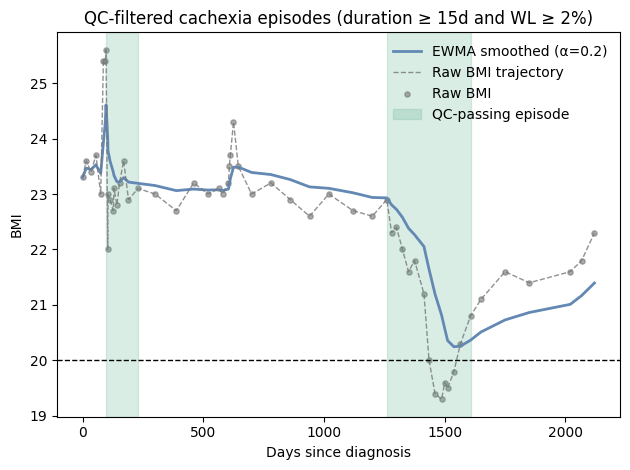

In [204]:
# =========================
# Step 6: Episode-level QC (duration + minimum WL%)
#   - Remove short or trivial episodes after merging.
# QC rules:
#   - episode_duration = end_day - start_day  >= 15 days
#   - weight_loss_pct  = (start_bmi - end_bmi) / start_bmi * 100  >= 2%
# # Output:
#   - valid_episodes: episodes that pass QC
# =========================

MIN_DUR = 15
MIN_WL_PCT = 2

qc_df = merged.copy()

qc_df["episode_duration"] = (qc_df["end_day"] - qc_df["start_day"]).astype(float)
qc_df["weight_loss_pct"] = (qc_df["start_bmi"] - qc_df["end_bmi"]) / qc_df["start_bmi"] * 100

valid_episodes = qc_df[
    (qc_df["episode_duration"] >= MIN_DUR) &
    (qc_df["weight_loss_pct"] >= MIN_WL_PCT)
].copy()


print("Merged episodes:", qc_df.shape[0])
print("Valid episodes after QC:", valid_episodes.shape[0])

plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in valid_episodes.dropna(subset=["start_day", "end_day"]).iterrows():
        plt.axvspan(r["start_day"], r["end_day"], alpha=0.22, color="#55AD89FF",
                    label="QC-passing episode" if "QC-passing episode" not in plt.gca().get_legend_handles_labels()[1] else None)

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("QC-filtered cachexia episodes (duration ≥ 15d and WL ≥ 2%)")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

Edema windows detected: 1


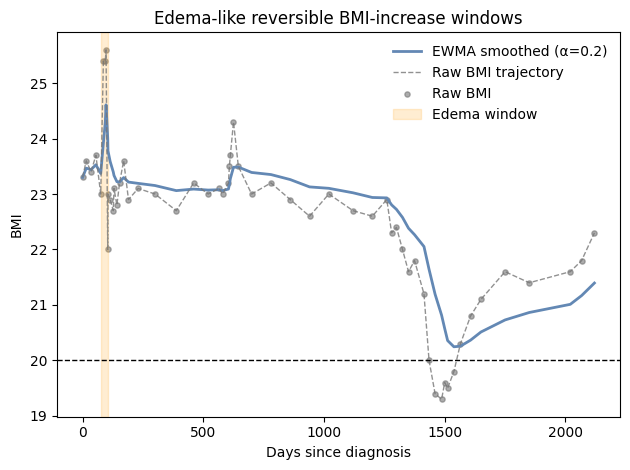

In [210]:
# =========================
# Step 7: Edema QC (remove episodes overlapping reversible BMI-increase windows)
#   - Identify edema-like windows: rapid reversible *increases* in log-smoothed BMI
#   - Remove cachexia episodes that overlap any edema window
# Parameters:
#   - window_days = 30
#   - up_frac = 0.05      (≥5% increase)
#   - return_frac = 0.02  (returns to within 2% of baseline)
# Output:
#   - edema_windows: merged edema windows for this patient
#   - valid_noed: QC-passing episodes after removing edema-overlapping episodes
# =========================
EDEMA_WINDOW_DAYS = 30
UP_FRAC = 0.05
RETURN_FRAC = 0.02

TIME_COL = "days_since_anchor"
LOG_COL  = "log_smoothed_BMI"

def identify_edema_windows_log(df_mrn, time_col, log_bmi_col,
                              window_days=30, up_frac=0.05, return_frac=0.02):
    """
    Detect edema-like reversible *increase* windows in log BMI:
      baseline -> >= baseline + log(1+up_frac) -> <= baseline + log(1+return_frac)
    within [baseline_day, baseline_day + window_days].
       """
    df_mrn = df_mrn[[time_col, log_bmi_col]].dropna().sort_values(time_col).reset_index(drop=True)
    if df_mrn.shape[0] < 3:
        return pd.DataFrame(columns=["ed_start_day", "ed_peak_day", "ed_end_day"])

    t = df_mrn[time_col].to_numpy()
    x = df_mrn[log_bmi_col].to_numpy()

    up_log = np.log(1.0 + up_frac)
    ret_log = np.log(1.0 + return_frac)

    out = []
    n = len(t)

    for i in range(n - 2):
        baseline_day = t[i]
        baseline_log = x[i]
        t_end = baseline_day + window_days

        j_end = np.searchsorted(t, t_end, side="right")
        if j_end <= i + 1:
            continue

        win_t = t[i+1:j_end]
        win_x = x[i+1:j_end]

        inc_idx_rel = np.where(win_x >= (baseline_log + up_log))[0]
        if inc_idx_rel.size == 0:
            continue

        peak_rel = inc_idx_rel[0]
        peak_day = win_t[peak_rel]

        after_x = win_x[peak_rel+1:]
        after_t = win_t[peak_rel+1:]
        if after_x.size == 0:
            continue

        ret_idx_rel = np.where(after_x <= (baseline_log + ret_log))[0]
        if ret_idx_rel.size == 0:
            continue

        end_day = after_t[ret_idx_rel[0]]
        out.append((baseline_day, peak_day, end_day))

    if len(out) == 0:
        return pd.DataFrame(columns=["ed_start_day", "ed_peak_day", "ed_end_day"])

    return pd.DataFrame(out, columns=["ed_start_day", "ed_peak_day", "ed_end_day"])


def merge_overlapping_windows(ed):
    """Merge overlapping edema windows (ed_start_day/ed_end_day)."""
    if ed.empty:
        return ed
    ed = ed.sort_values("ed_start_day").reset_index(drop=True)
    merged = []
    cur_s = ed.loc[0, "ed_start_day"]
    cur_e = ed.loc[0, "ed_end_day"]

    for k in range(1, ed.shape[0]):
        s = ed.loc[k, "ed_start_day"]
        e = ed.loc[k, "ed_end_day"]
        if s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e

    merged.append((cur_s, cur_e))
    return pd.DataFrame(merged, columns=["ed_start_day", "ed_end_day"])


def flag_episode_edema_overlap(ep_df, ed_df):
    """Add boolean edema_overlap for episodes that overlap any edema window."""
    ep_df = ep_df.copy()
    ep_df["edema_overlap"] = False

    for idx in ep_df.index:
        s = ep_df.at[idx, "start_day"]
        e = ep_df.at[idx, "end_day"]
        if pd.isna(s) or pd.isna(e):
            continue
        ep_df.at[idx, "edema_overlap"] = bool(((ed_df["ed_start_day"] <= e) & (ed_df["ed_end_day"] >= s)).any())

    return ep_df


ed_raw = identify_edema_windows_log(
    one, time_col=TIME_COL, log_bmi_col=LOG_COL,
    window_days=EDEMA_WINDOW_DAYS, up_frac=UP_FRAC, return_frac=RETURN_FRAC
)

edema_windows = merge_overlapping_windows(
    ed_raw[["ed_start_day", "ed_end_day"]]
) if not ed_raw.empty else pd.DataFrame(columns=["ed_start_day", "ed_end_day"])

print("Edema windows detected:", edema_windows.shape[0])

# =========================
#Plot edema windows only
# =========================
plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in edema_windows.iterrows():
    plt.axvspan(r["ed_start_day"], r["ed_end_day"], alpha=0.22, color="#FFAE34FF",
                label="Edema window" if "Edema window" not in plt.gca().get_legend_handles_labels()[1] else None)

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("Edema-like reversible BMI-increase windows")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


QC-passing episodes (pre-edema): 2
Episodes remaining (post-edema): 1


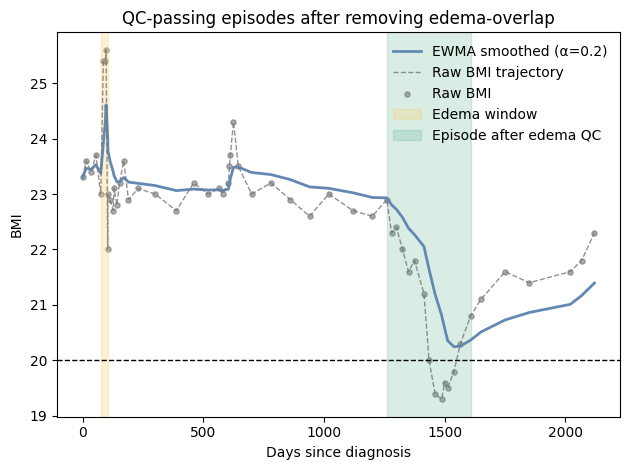

In [213]:
valid_flagged = flag_episode_edema_overlap(valid_episodes, edema_windows)
valid_noed = valid_flagged.loc[~valid_flagged["edema_overlap"]].copy()

print("QC-passing episodes (pre-edema):", valid_episodes.shape[0])
print("Episodes remaining (post-edema):", valid_noed.shape[0])

plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in edema_windows.iterrows():
    plt.axvspan(r["ed_start_day"], r["ed_end_day"], alpha=0.3, color="#F9D073FF",
                label="Edema window" if "Edema window" not in plt.gca().get_legend_handles_labels()[1] else None)

for _, r in valid_noed.iterrows():
    plt.axvspan(r["start_day"], r["end_day"], alpha=0.22, color="#55AD89FF",
                label="Episode after edema QC" if "Episode after edema QC" not in plt.gca().get_legend_handles_labels()[1] else None)

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("QC-passing episodes after removing edema-overlap")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

Final episodes (post duration/WL QC + edema QC): 1
 start_day  start_bmi  onset_day  onset_bmi  end_day  end_bmi  episode_duration  weight_loss_pct
      1260       22.9       1435      21.64     1607    20.37             347.0            11.07


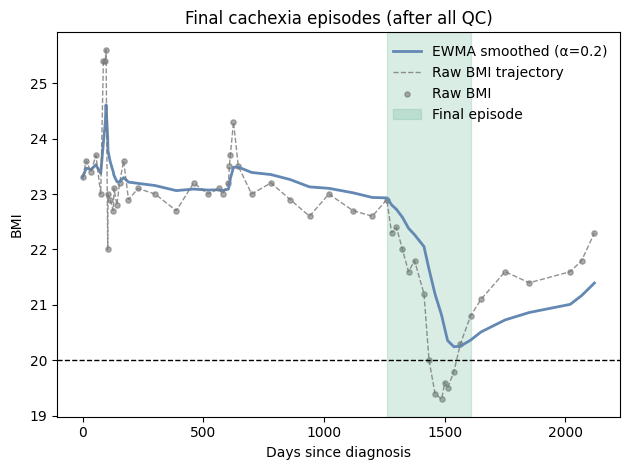

In [214]:
# =========================
#Episodes remaining after ALL QC (duration/WL + edema QC)
# Output:
#   - Plot: only the remaining final episodes (green)
#   - Print: one-line summary per remaining episode (start/end/duration/WL%)
# =========================

final_eps = valid_noed.copy()

final_eps["episode_duration"] = (final_eps["end_day"] - final_eps["start_day"]).astype(float)
final_eps["weight_loss_pct"]  = (final_eps["start_bmi"] - final_eps["end_bmi"]) / final_eps["start_bmi"] * 100

summary_cols = ["start_day", "start_bmi", "onset_day", "onset_bmi", "end_day", "end_bmi",
                "episode_duration", "weight_loss_pct"]
print("Final episodes (post duration/WL QC + edema QC):", final_eps.shape[0])

if final_eps.shape[0] == 0:
    print("No episodes remain after all QC.")
else:
    print(
        final_eps[summary_cols]
        .assign(
            start_day=lambda d: d["start_day"].astype(int),
            onset_day=lambda d: d["onset_day"].astype(int),
            end_day=lambda d: d["end_day"].astype(int),
            episode_duration=lambda d: d["episode_duration"].round(1),
            weight_loss_pct=lambda d: d["weight_loss_pct"].round(2),
            start_bmi=lambda d: d["start_bmi"].round(2),
            onset_bmi=lambda d: d["onset_bmi"].round(2),
            end_bmi=lambda d: d["end_bmi"].round(2),
        )
        .to_string(index=False)
    )

plt.figure()
plt.plot(one["days_since_anchor"], one["smoothed_BMI"], linewidth=2, color="#6388B4FF",
         label="EWMA smoothed (α=0.2)")
plt.plot(one["days_since_anchor"], one["bmi"], linewidth=1, linestyle="--",
         color="#767676FF", alpha=0.8, label="Raw BMI trajectory")
plt.scatter(one["days_since_anchor"], one["bmi"], s=14, color="#767676FF",
            alpha=0.6, label="Raw BMI")

for _, r in final_eps.iterrows():
    plt.axvspan(r["start_day"], r["end_day"], alpha=0.22, color="#55AD89FF",
                label="Final episode" if "Final episode" not in plt.gca().get_legend_handles_labels()[1] else None)

plt.axhline(20, color="black", linestyle="--", linewidth=1)
plt.title("Final cachexia episodes (after all QC)")
plt.xlabel("Days since diagnosis")
plt.ylabel("BMI")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()